<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Lab: Process Multimodal Data with LLMs**


Estimated time needed: **45** minutes


## **Scenario**


### **Background**

You transformed unstructured restaurant descriptions into a structured JSON knowledge base using LLMs. This allowed the app to reason over textual attributes such as cuisine type, pricing, and signature dishes in a consistent, machine-readable format.

However, the app’s data is not limited to text. It also includes **food recipes** and **user visit histories** that reference **images**, capturing visual information that text alone cannot fully describe, such as presentation style, ingredients, and portion details. To unlock this information and integrate it with the original databases, you will use multimodal GenAI capabilities to convert images into descriptive text and enrich the structured knowledge you have.


### **The challenge**

Images are inherently unstructured and cannot be directly stored or queried in a text-based knowledge system. To make them usable, you must first **generate high-quality textual descriptions** that summarize the visual content of each image.

Your challenge in this lab is to:

* Apply image captioning to generate descriptive text for food images
* Align and merge image captions with the corresponding recipe and restaurant JSON records
* Extend the existing structured knowledge base with multimodal context while preserving a consistent schema

By the end of this lab, you will have enriched your restaurant knowledge base with visual insights. You will bridge text and images into a unified, machine-accessible representation, setting the stage for more intelligent multimodal reasoning in later assignments.


## **Objectives**

In this lab, you will write a Python program that will:

* Load food recipe and user visit data containing image references
* Use a multimodal foundation model to generate textual captions for food images
* Integrate the generated image captions into the existing structured JSON data
* Produce an enriched multimodal JSON knowledge file for downstream applications


## **Important: About the lab environment**


Please be aware that sessions for this lab environment are not persisted. Every time you connect to this lab, a new environment is created for you. Any data you may have saved in the earlier session would get lost. Plan to complete these labs in a single session, to avoid losing your data.


## **Screenshot requirement for this lab**


You will be prompted to take a screenshot and save it on your own device. You will need this screenshot either to answer graded quiz questions or to upload as your submission for the Final Project at the end of this course. You can use various free screen-grabbing tools or your operating system's shortcut keys to do this (for example, `Alt+PrintScreen` on Windows and `Command+shift+4` on Mac).
**Note**: The screenshot can be saved with either the **.jpg** or **.png** extension.


----


## **Set up the lab environment**


For this lab, you will still be using the following libraries:

* [`numpy`](https://numpy.org/) for numerical operations and handling array-based data during preprocessing and analysis

* [`matplotlib`](https://matplotlib.org/) for basic data visualization and plotting, useful for inspecting distributions or intermediate results

* [`json`](https://docs.python.org/3/library/json.html) for parsing, constructing, and serializing structured JSON representations extracted from unstructured text

* **IBM watsonx AI SDK** (`ibm-watsonx-ai`) for interacting with foundation models hosted on IBM watsonx.ai:

  * `Credentials` to securely authenticate with the watsonx.ai service
  * `ModelInference` to invoke foundation models for text understanding and information extraction
  * `GenTextParamsMetaNames` to configure text generation and extraction parameters
  * `ModelTypes` and `DecodingMethods` to select the appropriate model and control inference behavior

These libraries together enable you to transform images into text-based data using GenAI-powered workflows.


### Installing required libraries

Run the following code block to install all required libraries:


In [31]:
%%capture
%pip install numpy==2.3.4
%pip install matplotlib==3.10.7
%pip install ibm-watsonx-ai==1.4.7

### Importing required libraries

It is recommended to import all required libraries in one place (here):


In [32]:
import numpy as np
import matplotlib.pyplot as plt
import json
import os
from PIL import Image

# IBM WatsonX imports
from ibm_watsonx_ai import Credentials
from ibm_watsonx_ai.foundation_models import ModelInference
from ibm_watsonx_ai.metanames import GenTextParamsMetaNames as GenParams
from ibm_watsonx_ai.foundation_models.utils.enums import (
    ModelTypes,
    DecodingMethods,
)

# Libraries and codes to suppress warnings generated by your code:
def warn(*args, **kwargs):
    pass
import warnings
warnings.warn = warn
warnings.filterwarnings('ignore')

### Fetch the data file

Run the following code to fetch the food recipe, user visit history, and recipe images.


In [33]:
!wget https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/hpTjb6liKBLVHQK0UgMi5A/Recipes.json
!wget https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/fQUs9wQ6aB6ts6fmkD2V2w/Synthetic-User-Reviews.json
!wget https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/5_Rr6ohviItzucyWk6nkrw/synthetic-recipe-images.zip

--2026-05-16 16:44:37--  https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/hpTjb6liKBLVHQK0UgMi5A/Recipes.json
Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 169.63.118.104
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|169.63.118.104|:443... connected.
200 OKequest sent, awaiting response... 
Length: 66320 (65K) [application/json]
Saving to: ‘Recipes.json.1’

Recipes.json.1      100%[===================>]  64.77K  --.-KB/s    in 0.002s  

2026-05-16 16:44:37 (30.5 MB/s) - ‘Recipes.json.1’ saved [66320/66320]

--2026-05-16 16:44:38--  https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/fQUs9wQ6aB6ts6fmkD2V2w/Synthetic-User-Reviews.json
Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 169.63.118.104
Con

Run the following code to unzip the image folder:


In [34]:
import zipfile

with zipfile.ZipFile("synthetic-recipe-images.zip", 'r') as zip_ref:
    zip_ref.extractall()

----


## **Exercise 1: Preprocess the food reciepe data**


### Step 1: Explore the food recipe JSON File and its images

Before applying any multimodal processing, it is important to understand the structure and contents of the data you will be working with. In this step, you will load the food recipe JSON file and examine its fields, including textual metadata and image references.

You will also inspect a sample of the associated food images to understand the visual information they contain, such as ingredients, presentation style, and portion size. This exploration step helps you identify how the image data aligns with recipe metadata and prepares you for integrating image captions into the existing JSON structure in later steps.

By the end of this step, you should have a clear understanding of how the recipe data and images are organized, and how they relate to the structured restaurant knowledge built in the previous lesson.


In [35]:
### Your Code Here
### Step 1.1: Load the json file. Define the loaded data as recipe_data.
file_name = "Recipes.json"
with open(file_name,"r") as file:
    recipe_data = json.load(file)
### Step 1.2: Print each key-value pair of the first recipe. In this format: key (type of value): value
first_recipe = recipe_data[0]

for key,value in first_recipe.items():
    value_type = type(value).__name__
    print(f"{key} ({value_type}): {value}")
### Step 1.3: Show the image of the first recipe (recipe1)

id (int): 1
name (str): Classic Margherita Pizza
cuisine (str): Italian
servings (int): 2
prep_time (str): 20 mins
cook_time (str): 15 mins
total_time (str): 35 mins
ingredients (list): ['1 pizza dough ball (about 260g)', '2 tablespoons tomato sauce', '1 cup shredded mozzarella cheese', '6-8 fresh basil leaves', '1 tablespoon olive oil', 'pinch of salt', 'optional: grated parmesan']
directions (list): ['Preheat oven to 250°C (482°F) with a baking stone if available.', 'Roll out dough to a 12-inch circle on a floured surface.', 'Spread tomato sauce evenly over dough, leaving a 1/2-inch border.', 'Scatter mozzarella cheese over sauce.', 'Bake on the stone for 10-12 minutes until crust is crisp and cheese melts.', 'Finish with basil leaves, drizzle with olive oil, and season with salt and optional parmesan.', 'Slice and serve immediately.']


### Step 2: Define the vision LLM with LLaMA

To generate meaningful textual descriptions from food images, you will use a vision-capable large language model (LLM). In this step, you will define and configure a **LLaMA-based vision model** that can process both images and text prompts.

You will initialize the model with the appropriate credentials and inference parameters, and verify that it accepts image inputs and produces descriptive captions. This model will serve as the core component for converting visual information into natural language that can be integrated with your existing JSON-based knowledge structure.

By completing this step, you will have a vision-enabled LLM ready to perform image captioning reliably and repeatably.


In [36]:
### Your Code Here: Fill in the blanks
import base64

def vision_llm(system_msg, prompt_txt, image_path):
    #system_msg: input system message for the LLM
    #prompt_txt: input user prompt for the LLM
    #image_path: the file path of the input image

    ### Credentials of the model
    model_id = 'meta-llama/llama-4-maverick-17b-128e-instruct-fp8'
    project_id="skills-network"
    credentials = Credentials(
                    url = "https://us-south.ml.cloud.ibm.com",
                    )

        ### Step 2.1: Define the model by ModelInference
    model = ModelInference(
        credentials = credentials,
        model_id = model_id,
        project_id = project_id)
    
    ### Step 2.2: Encode the input image to a base64 string
    with open(image_path, "rb") as image_file:
        encoded_image = base64.b64encode(image_file.read()).decode("utf-8")

    ### Step 2.3: Define the messages for the model
    messages = [
        {
            "role": "system",
            "content": [
                {"type": "text", "text": system_msg}
            ]
        },
        {
            "role": "user",
            "content": [
                {"type": "text", "text": prompt_txt},
                {
                    "type": "image_url",
                    "image_url": {
                        "url": f"data:image/png;base64,{encoded_image}"
                    }
                }
            ]
        }
    ]

    ### Step 2.4: Get the response for the messages
    response = model.chat(messages=messages)
    return response

### Step 3: Design and validate prompts for the vision LLM

To ensure the vision LLM generates useful and consistent image captions, careful prompt design is essential. In this step, you will create a prompt that instructs the model to focus on relevant visual details, such as ingredients, cooking style, and presentation, while avoiding unnecessary or speculative information.

Once the prompt is defined, you will perform a simple unit test by running the model on a small sample of food images. This allows you to verify that the generated captions are accurate, concise, and suitable for integration into the existing JSON data structure.

By the end of this step, you will have a validated prompt that reliably converts food images into high-quality textual descriptions.


In [37]:
### Your Code Here

### Define the food image caption prompts given a food name.
### The food name, as you have noticed, comes from the corresponding recipe data.
### You want to include the food name to ensure the model focuses on it while giving captions.
def image_caption_prompt_template(food_name):
    # food_name: the food name of the recipe

    ### Step 3.1: Design the prompts
    image_caption_system_msg = "You are a food expert. Analyze the image and provide a caption."
    image_caption_prompt_txt = "Describe its visual appereance, style..."

    return image_caption_system_msg, image_caption_prompt_txt


### Test the prompts on the first recipe
### Step 3.2: Get the prompts with the food name of the first recipe
first_recipe_name = first_recipe["name"]
system_msg, prompt_txt = image_caption_prompt_template(first_recipe_name)
### Step 3.3: Get the test response and print it
image_path = "synthetic_recipe_images/recipe1.png" 
response = vision_llm(system_msg,prompt_txt,image_path)
final_response = response["choices"][0]["message"]["content"] 
print(final_response)

The image depicts a pizza on a wooden serving board, accompanied by a small bowl of sauce and a glass of olive oil.

*   The pizza is the central focus of the image.
    *   It has a golden-brown crust with dark spots, indicating it was cooked in a wood-fired oven.
    *   The pizza is topped with tomato sauce, melted cheese, and fresh basil leaves arranged in a circular pattern.
    *   One slice has been removed from the pizza.
*   The pizza is placed on a round wooden serving board.
    *   The board is positioned on a beige surface, possibly a table or countertop.
    *   A piece of parchment paper is visible under the pizza.
*   A small white bowl containing red sauce is situated behind the pizza.
    *   The bowl is partially out of frame.
    *   The sauce appears to be tomato-based.
*   A glass of olive oil is located in the top-right corner of the image.
    *   The glass is partially out of frame.
    *   The olive oil is yellowish-green in color.

The image presents a visual

### Step 4: Caption all images and augment the data

With a validated prompt and a working vision LLM, you will now scale the image captioning process across the entire dataset. In this step, you will iterate through all food images, generate captions for each one, and associate the results with their corresponding recipe or restaurant records.

You will then augment the existing JSON data by adding the generated image captions as new fields, ensuring the final structure remains consistent and machine-readable. This enriched dataset combines textual and visual insights into a unified representation, extending the structured knowledge base created in the previous lessons.

By the end of this step, you will have a multimodal JSON file that integrates image-derived descriptions with existing structured data, ready for downstream GenAI applications.


In [40]:
### Your Code Here:

### Get captions for each image in the dataset and add to the JSON file (up tp 15 minutes)
### recipe_data is the recipe you loaded in Step 1
for i in range(len(recipe_data)):
    if (i+1)%20 == 0:
        print(f'{i+1} out of {len(recipe_data)} is done')

    ### Step 4.1: Get the caption prompts
    food_name = recipe_data[i]["name"]
    system_msg, prompt_msg = image_caption_prompt_template(food_name)
    ### Step 4.2: Get the response with the prompts
    image_path = f"synthetic_recipe_images/recipe{i+1}.png"
    response = vision_llm(system_msg,prompt_txt,image_path)

    ### Save the response as another item in the recipe data
    caption = response["choices"][0]["message"]["content"]
    recipe_data[i]['image_description'] = response
print('ALL DONE!')


20 out of 109 is done
40 out of 109 is done
60 out of 109 is done
80 out of 109 is done
100 out of 109 is done
ALL DONE!


Take a screenshot of the Python code, clearly showing your implementation and the output from Step 2. Name the screenshot ```M1L2_caption_all_recipes.jpg```. 


### Step 5: Save the image-caption-augmented recipe data

Save your data by running the following code.


In [41]:
filename = 'augmented_food_recipe.json'
with open(filename, 'w', encoding='utf-8') as f:
    json.dump(recipe_data, f, indent=4)

You can download the saved JSON file to your local folder. Be sure to store it in a safe location, as you will need it for future assignments.


----


## **Exercise 2: Preprocess the user visit history**

In this exercise, you will largely replicate the workflow from **Exercise 1**. The core steps, data exploration, prompt design, model inference, and JSON augmentation, remain the same.

The key difference lies in **prompt design**. Instead of focusing on food images, you will tailor your prompt to generate concise, informative descriptions from user visit history data, such as contextual cues from URLs or associated images combined with their written reviews. These prompts should emphasize elements that help explain user preferences and behavior while maintaining consistency with the existing JSON schema.

By the end of this exercise, you will have enriched the user visit history data with structured, machine-readable descriptions, further expanding the multimodal knowledge base built throughout this lab.


### Step 1: Load the user review data

Similar to Step 1 of Exercise 1, complete the following code block to load and explore the user review data.


In [43]:
### Part 1
### Your Code Here

### Step 1.1: Load the review dataset with variable name user_review_data
file_name = "Synthetic-User-Reviews.json"
with open(file_name,"r") as file:
    user_review_data = json.load(file)
### Step 1.2: Print the first review by key-value pairs

first_review = user_review_data[0]

for key,value in first_review.items():
    value_type = type(value).__name__
    print(f"{key} ({value_type}): {value}")


reviewId (int): 900000001
userId (str): USER_FUSION_FINDER_99
itemId (int): 1000001
title (str): A bit pricey, but that greenhouse vibe is so cozy
text (str): The Gilded Artichoke is definitely an upscale splurge. The lavender-rubbed chicken is unique, almost giving me tea-smoked vibes. It's a gorgeous, plant-filled escape from the city, though your wallet will feel it.
date (str): 2025-11-15
rating (float): 4.5
language (str): en
images (str): ['https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/L0HyLOGuAlxwKZaCC8sJdg/Gemini-Generated-Image-523rkg523rkg523r.png','https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/YLCD9AYY985XxvP-K8CRbA/Gemini-Generated-Image-hy4y8why4y8why4y.png']


Let's look at the 'images' item. Although it looks like a list, it is actually a list in string type. Therefore, you need to be careful and convert the string to the actual Python list. Complete the code block below to display the first review image of the first restaurant visit.


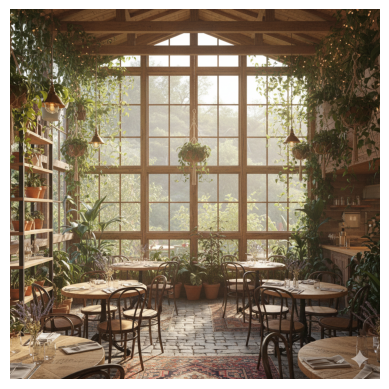

In [68]:
### Part 2
### Your Code Here

### Get the image by requesting from the URL
import ast # needed to convert string representation of list to actual python list
import requests

### Convert the list of images of the first user into the actual python list
### Step 1.3: Use ast.literal_eval to convert
image_list = ast.literal_eval(first_review["images"])
### Step 1.4: Use the requests.get() method to get the image content
response= requests.get(image_list[0])

### Step 1.5: Write the image content in Step 1.4 to a temporary file 'review_image_placeholder.jpg'
with open("review_image_placeholder.jpg", "wb") as file:
    file.write(response.content)

### Step 1.6: Open the 'review_image_placeholder.jpg', and show th image
img = Image.open("review_image_placeholder.jpg")

plt.imshow(img)
plt.axis("off")
plt.show()


### Step 2: Define the prompt and the validation

Again, you will design a prompt template for the vision task and perform a unit test to validate the model’s behavior. However, unlike the previous exercise, this prompt must **incorporate textual context from user reviews** to guide the image captioning process.

In this step, you will define a prompt template function that takes user review text as input and uses it as contextual information when describing a food image. The system message assigns the model the role of a culinary expert, while the prompt instructs the model to generate a concise image description that aligns with the sentiment and details expressed in the reviews.

After defining the prompt template, you will perform a unit test by running the vision LLM on a single image and its associated reviews. This test allows you to verify that the generated caption effectively combines visual information from the image with contextual cues from the reviews before applying the prompt at scale in later steps.


In [70]:
### Your Code Here:
### Prompt template: caption the images with the context of the reviews
def review_context_image_caption_prompt_template(reviews):
    # reviews: the written review content


    ### Step 2.1: Design your prompts
    review_context_image_caption_system_msg = "You are an image captioning specialist for restaurant review images. Use the written review as extra context."
    review_context_image_caption_prompt_txt = f"Please write a concise caption for the image. Written review context {reviews}"

    return review_context_image_caption_system_msg, review_context_image_caption_prompt_txt 

### Step 2.2: Get the prompts
reviews = first_review.get("reviewText", first_review.get("text", str(first_review)))

system_msg, prompt_txt = review_context_image_caption_prompt_template(reviews)
### Step 2.3: Get the response by the vision_llm you defined previously
response = vision_llm(system_msg,prompt_txt,"review_image_placeholder.jpg")
caption = response["choices"][0]["message"]["content"]
print(caption)

The Gilded Artichoke's serene greenhouse dining area, where lush greenery and natural light create a tranquil ambiance, perfect for a luxurious dining experience.


### Step 3: Caption all images and augment the data

Now, you are ready to get all captions with a for loop! Complete and run the following code block to caption all the review images.


In [ ]:
### Your Code Here

from tenacity import retry, stop_after_attempt, wait_exponential

### URL Request function with Retry
# Retries up to 10 times, starting at 1s and doubling (1s, 2s, 4s...)
@retry(stop=stop_after_attempt(10), wait=wait_exponential(multiplier=1, min=1, max=10))
def get_data_with_retry(url):
    response = requests.get(url, timeout=5)
    response.raise_for_status() # Must raise error for retry to trigger
    return response

### Start the for loop
for i in range(len(user_review_data)):
    ### Step 3.1: Convert the string to the Python list of image urls
    review_images = user_review_data[i]["images"]
    
    if isinstance(review_images, str):
        review_images = ast.literal_eval(review_images)
        
    review_image_captions = []
    if len(review_images) > 0:
        for img_url in review_images:
            try:
                ### Step 3.2: Use get_data_with_retry to get the image_data
                image_data = get_data_with_retry(img_url)
                print("Success!")
            except Exception as e:
                print(f"All retries failed at url {img_url}:", e)
                continue
            image = image_data.content
            with open('review_image_placeholder.jpg', 'wb') as img_file:
                img_file.write(image)

            ### Step 3.3: Get the prompts, get the response, and finally append the response to review_image_captions
            reviews = user_review_data[i].get("reviewText", "")

            system_msg, prompt_txt = review_context_image_caption_prompt_template(reviews)

            response = vision_llm(
                image_path="review_image_placeholder.jpg",
                system_msg=system_msg,
                prompt_txt=prompt_txt
            )

            review_image_captions.append(response)
            
    ### Append the review_image_captions to the review data
    user_review_data[i]['image_captions'] = review_image_captions
print('ALL DONE!')

Success!
Success!
Success!
Success!
Success!
Success!
Success!


### Step 4: Save the image-caption-augmented user review data


Run the following code block to save the augmented review data:


In [ ]:
filename = 'augmented_user_review.json'
with open(filename, 'w', encoding='utf-8') as f:
    json.dump(user_review_data, f, indent=4)

You can download the saved JSON file to your local folder. Be sure to store it in a safe location, as you will need it for future assignments.


----


## **Conclusion**

You have successfully applied GenAI tools to transform the unstructured text data into a well-structured JSON file!

----


## Authors


[Jianping (Mike) Ye](https://www.linkedin.com/in/jianping-ye/)


<!--## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|
|2026-02-03|1|Jianping Ye|Create lab|
|2026-02-10|2|Jojy John|ID Reviewed|-->



©IBM Corporation. All rights reserved.
